# Exploratory data analysis for footbal dataset

Data visualisation group project: Group 10

In [ ]:
# Import the relevant libraries
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load the data from a db file

# Change the path to the football.db file
PATH_TO_DB = 'football.db'

SQL_ENDPOINT = f"sqlite+pysqlite:///{PATH_TO_DB}" # No need to change this

# Use this format to make a SQL query to the database
# The result will be a Pandas dataframe containing the result of that query
# Use this if you need to join tables together
# Tip: design the query in DBeaver first, because it has a better SQL editor and it understands the relationship between the tables
sql_query = pd.read_sql_query("""
select p.name, ge.description
from players p
join game_events ge on p.player_id = ge.player_id
where p.name = "Lucas Digne" and ge.type = 'Goals'
""",
SQL_ENDPOINT,
dtype_backend="numpy_nullable")

# Use this format to get one of the tables from the database
# The result will be a Pandas dataframe containing the requested table, in this example "players"
# Use this if you just need one of the tables without anything else
# You could also load the csv file in directly if you wanted to, but this is a bit nicer
sql_table = pd.read_sql_table("players", SQL_ENDPOINT, dtype_backend="numpy_nullable")

# Show the contents of the table
sql_table

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184,,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000,30000000
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190,,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000,8000000
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,,,,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000,34500000
3,77,,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,,,,,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000,24500000
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194,,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000,3000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32596,1375876,,Diego Henrique,Diego Henrique,2024,86209,diego-henrique,Brazil,"Andradina, SP",Brazil,...,left,170,2026-06-30 00:00:00,,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/diego-henrique...,UKR1,FK Livyi Bereh,,
32597,1378362,Orseer,Achihi,Orseer Achihi,2024,1096,orseer-achihi,,,Nigeria,...,,,2029-06-30 00:00:00,Aneke/PMG,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/orseer-achihi/...,BE1,Royal Antwerp Football Club,,
32598,1380311,Prince Amoako,Junior,Prince Amoako Junior,2024,2778,prince-amoako-junior,,,Ghana,...,,,2029-12-31 00:00:00,CAA Stellar,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/prince-amoako-...,DK1,Fodbold Club Nordsjælland,,
32599,1380876,Gabriel Jesus,David,Gabriel Jesus David,2024,1096,gabriel-jesus-david,,,Nigeria,...,,,2025-06-30 00:00:00,Aneke/PMG,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/gabriel-jesus-...,BE1,Royal Antwerp Football Club,,


In [4]:
all_seasons = pd.read_sql_query("""
WITH big5_clubs AS (
    SELECT club_id, name, domestic_competition_id
    FROM clubs
    WHERE domestic_competition_id IN ('ES1', 'FR1', 'IT1', 'GB1', 'L1')
),
big5_club_games AS (
    SELECT
        cg.club_id,
        cg.game_id,
        cg.hosting,
        cg.is_win,
        cg.own_goals,
        cg.opponent_goals,
        g.season,
        NULLIF(
            CASE 
                WHEN cg.hosting = 'Home' THEN g.home_club_formation
                WHEN cg.hosting = 'Away' THEN g.away_club_formation
                ELSE NULL
            END,
        '') AS formation
    FROM club_games cg
    JOIN games g       ON cg.game_id = g.game_id
    JOIN big5_clubs b5 ON cg.club_id = b5.club_id
)
SELECT
    season,
    formation,
    COUNT(*) AS matches_played,
    ROUND(AVG(is_win), 3) AS win_rate
FROM big5_club_games
WHERE formation IS NOT NULL
GROUP BY season, formation
HAVING COUNT(*) >= 10
ORDER BY season, matches_played DESC;
""", SQL_ENDPOINT, dtype_backend="numpy_nullable")

all_seasons

,season,formation,matches_played,win_rate
0,2013,4-2-3-1,1770,0.411
1,2013,4-4-2 double 6,574,0.392
2,2013,4-3-3 Attacking,572,0.453
3,2013,3-5-2 flat,283,0.406
4,2013,4-1-4-1,239,0.393
...,...,...,...,...
220,2024,3-5-2,27,0.333
221,2024,4-4-1-1,26,0.346
222,2024,4-3-1-2,26,0.308
223,2024,4-4-2 Diamond,12,0.083


# ONLY LOOKING at the 2024 season

/var/folders/cd/6hxsrt5s1zv4znshprklx9qm0000gn/T/ipykernel_47502/1904214822.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=winrate_byformation_big5, x='formation', y='win_rate', palette='viridis')


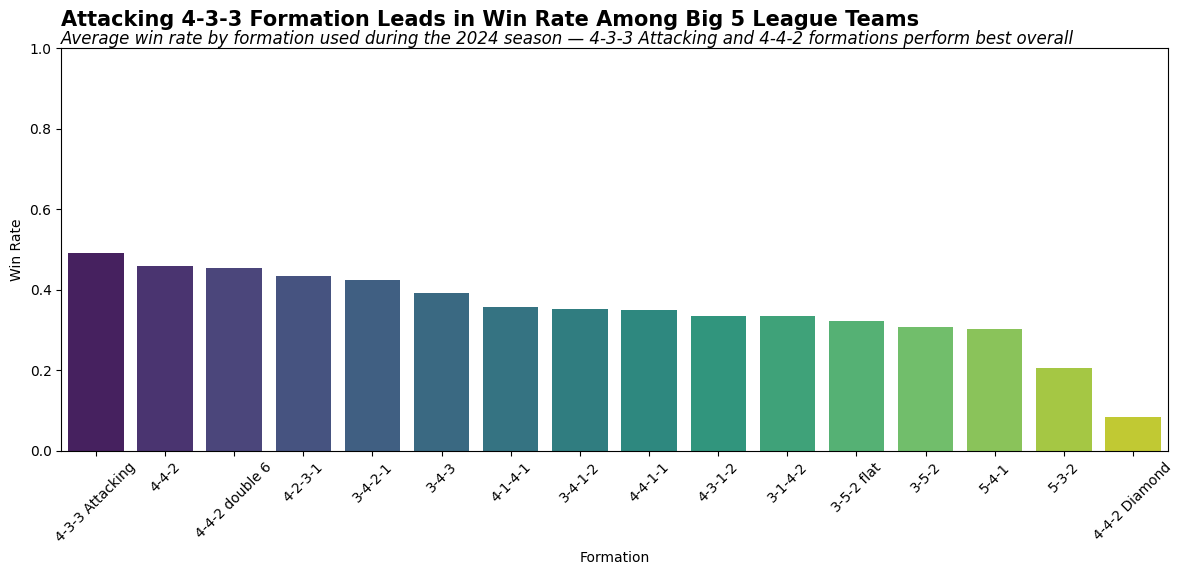

In [6]:
# looking at team thats is the big 5 leagues
teams_inbig5 = pd.read_sql_query("""
SELECT *
FROM clubs
WHERE domestic_competition_id IN ('ES1', 'FR1', 'IT1', 'GB1', 'L1')
  AND last_season = 2024;
""",
SQL_ENDPOINT,
dtype_backend="numpy_nullable")

teams_inbig5

# Looking at the win rate with different formations overall for teams that are in the big 5 leagues
winrate_byformation_big5 = pd.read_sql_query("""
WITH big5_clubs AS (
    SELECT club_id, name, domestic_competition_id
    FROM clubs
    WHERE domestic_competition_id IN ('ES1', 'FR1', 'IT1', 'GB1', 'L1')
      AND last_season = 2024
),
big5_club_games AS (
    SELECT
        cg.club_id,
        cg.game_id,
        cg.hosting,
        cg.is_win,
        cg.own_goals,
        cg.opponent_goals,
        g.season,
        CASE 
            WHEN cg.hosting = 'Home' THEN g.home_club_formation
            WHEN cg.hosting = 'Away' THEN g.away_club_formation
            ELSE NULL
        END AS formation
    FROM club_games cg
    JOIN games g       ON cg.game_id = g.game_id
    JOIN big5_clubs b5 ON cg.club_id = b5.club_id
    WHERE g.season = 2024
)
SELECT
    formation,
    COUNT(*) AS matches_played,
    SUM(CASE WHEN is_win = 1 THEN 1 ELSE 0 END) AS wins,
    ROUND(AVG(is_win), 3) AS win_rate
FROM big5_club_games
WHERE formation IS NOT NULL
GROUP BY formation
HAVING COUNT(*) >= 10  
ORDER BY win_rate DESC, matches_played DESC;
""",
SQL_ENDPOINT,
dtype_backend="numpy_nullable")

winrate_byformation_big5

# Visualize the win rate by formation for big 5 league teams
plt.figure(figsize=(12, 6))
sns.barplot(data=winrate_byformation_big5, x='formation', y='win_rate', palette='viridis')
plt.suptitle(
    "Attacking 4-3-3 Formation Leads in Win Rate Among Big 5 League Teams",
    fontsize=15, weight='bold', y=0.95, x=0.055, ha='left'
)
plt.title(
    "Average win rate by formation used during the 2024 season — 4-3-3 Attacking and 4-4-2 formations perform best overall",
    fontsize=12, style='italic', pad=2, loc='left'
)
plt.xlabel('Formation')
plt.ylabel('Win Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

How I Got to the Graph:
First, using SQL, I filtered the clubs table to include only teams from the Big 5 leagues (Premier League, La Liga, Serie A, Bundesliga, and Ligue 1) in the 2024 season.

Then, I combined match data from the club_games and games tables to find out which formation each team used and whether they won. I grouped the data by formation, counted how many games were played and won, and calculated the average win rate for each formation.

To keep the results reliable, I only included formations that were used in at least 10 matches.

Finally, I used Seaborn and Matplotlib to create a bar chart showing the win rate for each formation.

The graph shows that:
The Attacking 4-3-3 formation had the highest win rate.
Traditional systems like 4-4-2 and 4-2-3-1 also performed well.
More defensive setups (e.g., 5-3-2, 4-4-2 Diamond) tended to have lower win rates.

In [7]:
# Looking at the win rate with different formation for different leagues for teams that are in the big 5 leagues
winrate_byformation_league_big5 = pd.read_sql_query("""
WITH big5_clubs AS (
    SELECT club_id, name, domestic_competition_id
    FROM clubs
    WHERE domestic_competition_id IN ('ES1', 'FR1', 'IT1', 'GB1', 'L1')
      AND last_season = 2024
),
big5_club_games AS (
    SELECT
        cg.club_id,
        b5.domestic_competition_id AS league,
        cg.game_id,
        cg.hosting,
        cg.is_win,
        cg.own_goals,
        cg.opponent_goals,
        g.season,
        CASE 
            WHEN cg.hosting = 'Home' THEN g.home_club_formation
            WHEN cg.hosting = 'Away' THEN g.away_club_formation
            ELSE NULL
        END AS formation
    FROM club_games cg
    JOIN games g       ON cg.game_id = g.game_id
    JOIN big5_clubs b5 ON cg.club_id = b5.club_id
    WHERE g.season = 2024
)
SELECT
    league,
    formation,
    COUNT(*) AS matches_played,
    SUM(is_win) AS wins,
    ROUND(AVG(is_win), 3) AS win_rate
FROM big5_club_games
WHERE formation IS NOT NULL
GROUP BY league, formation
HAVING COUNT(*) >= 20 -- Increased threshold to 20 for more robust stats
ORDER BY league, win_rate DESC, matches_played DESC;
""",
SQL_ENDPOINT,
dtype_backend="numpy_nullable")

winrate_byformation_league_big5

,league,formation,matches_played,wins,win_rate
0,ES1,4-4-2,120,58,0.483
1,ES1,4-3-3 Attacking,123,58,0.472
2,ES1,4-2-3-1,320,144,0.45
3,ES1,5-4-1,52,17,0.327
4,ES1,4-4-2 double 6,28,9,0.321
5,ES1,4-1-4-1,47,15,0.319
6,FR1,4-3-3 Attacking,133,62,0.466
7,FR1,3-4-2-1,46,20,0.435
8,FR1,4-2-3-1,179,70,0.391
9,FR1,3-4-3,80,31,0.388


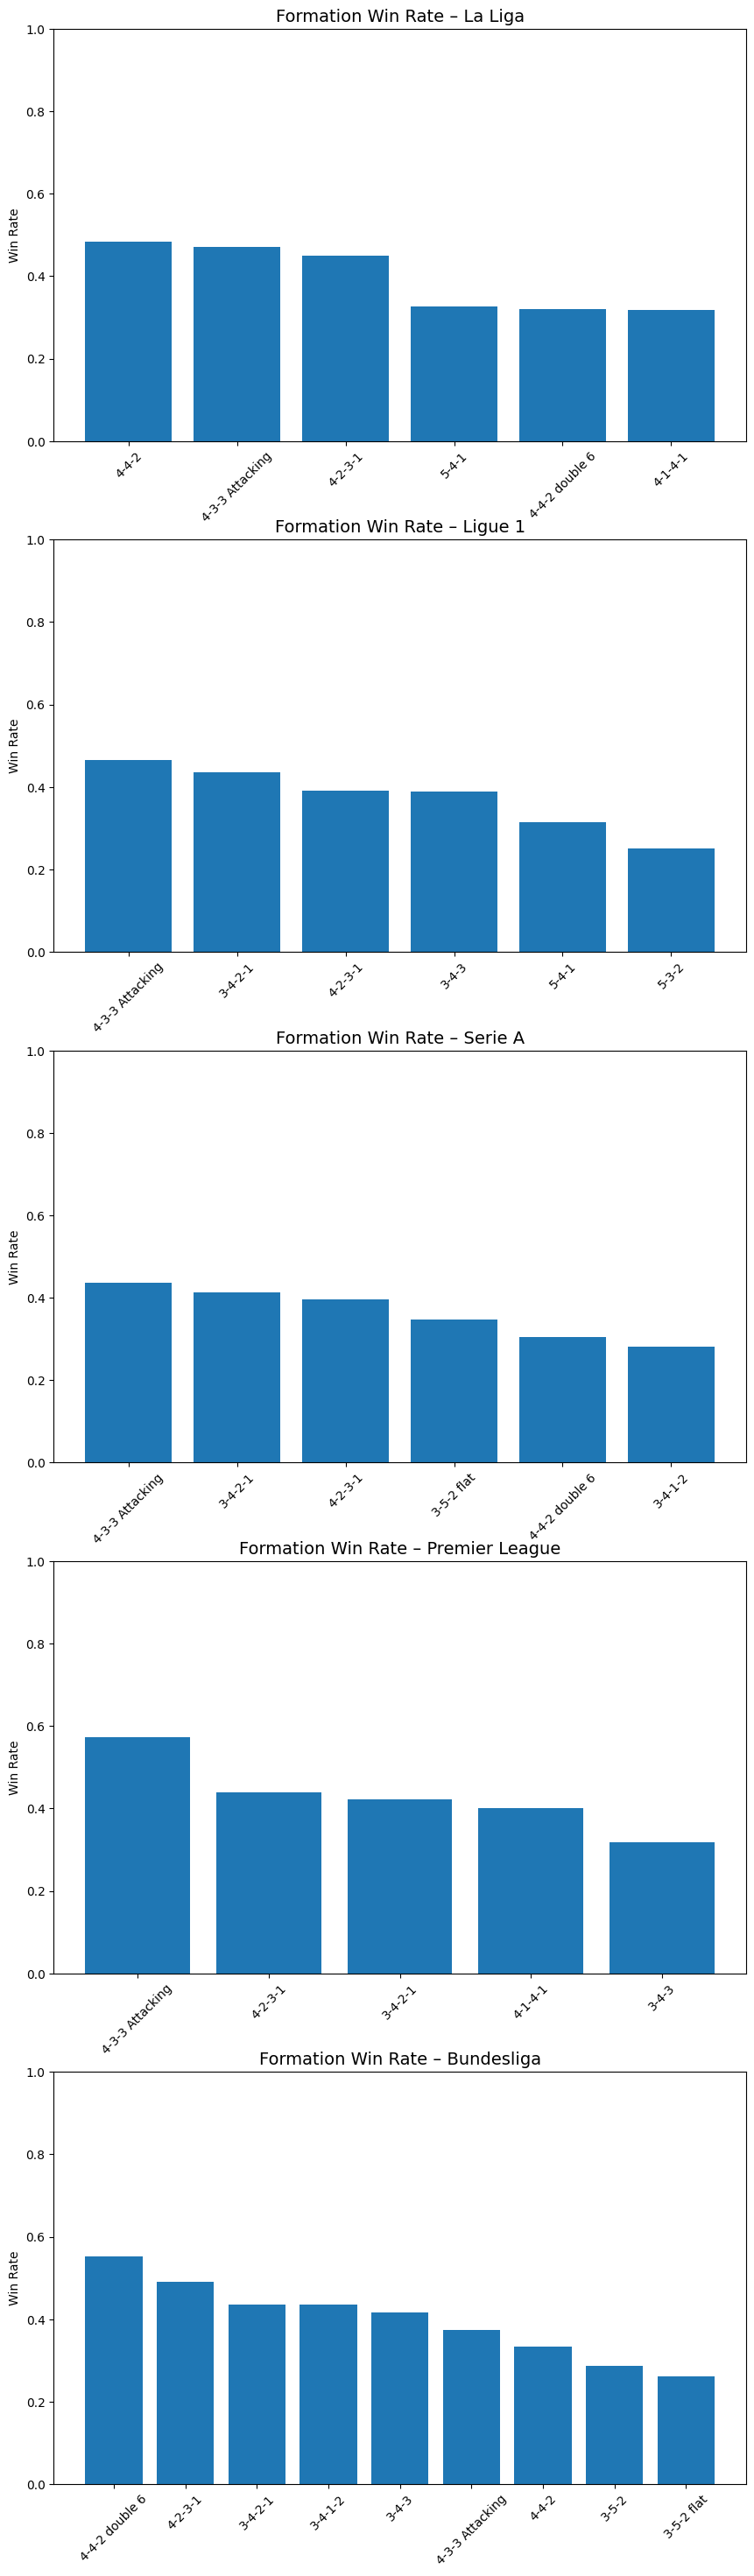

In [8]:
# now plotting these results
df = winrate_byformation_league_big5.copy()

leagues = ['ES1', 'FR1', 'IT1', 'GB1', 'L1']
league_names = {
    'ES1': 'La Liga',
    'FR1': 'Ligue 1',
    'IT1': 'Serie A',
    'GB1': 'Premier League',
    'L1': 'Bundesliga'
}

# Create 5 separate subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 30))
fig.tight_layout(pad=6)

for ax, league in zip(axes, leagues):
    data = df[df['league'] == league].sort_values('win_rate', ascending=False)

    ax.bar(data['formation'], data['win_rate'])
    ax.set_title(f"Formation Win Rate – {league_names[league]}", fontsize=14)
    ax.set_ylabel("Win Rate")
    ax.set_ylim(0, 1)  # win rate between 0–1
    ax.tick_params(axis='x', rotation=45)

plt.show()



In [9]:
# Looking at the best managers in the big 5 leagues based on win rate
best_managers_big5 = pd.read_sql_query("""
WITH big5_clubs AS (
    SELECT club_id, name, domestic_competition_id
    FROM clubs
    WHERE domestic_competition_id IN ('ES1', 'FR1', 'IT1', 'GB1', 'L1')
      AND last_season = 2024
),
big5_manager_games AS (
    SELECT
        cg.club_id,
        b5.name AS club_name,
        b5.domestic_competition_id AS league,
        cg.own_manager_name AS manager_name,
        cg.is_win,
        g.season
    FROM club_games cg
    JOIN games g       ON cg.game_id = g.game_id
    JOIN big5_clubs b5 ON cg.club_id = b5.club_id
    WHERE g.season = 2024
      AND cg.own_manager_name IS NOT NULL
)
SELECT
    manager_name,
    league,
    COUNT(*) AS matches_managed,
    SUM(is_win) AS wins,
    ROUND(AVG(is_win), 3) AS win_rate
FROM big5_manager_games
GROUP BY manager_name, league
HAVING COUNT(*) >= 5
ORDER BY wins DESC;
""",
SQL_ENDPOINT,
dtype_backend="numpy_nullable")

best_managers_big5

,manager_name,league,matches_managed,wins,win_rate
0,Hansi Flick,ES1,48,36,0.75
1,Arne Slot,GB1,49,35,0.714
2,Carlo Ancelotti,ES1,51,34,0.667
3,Luis Enrique,FR1,42,32,0.762
4,Simone Inzaghi,IT1,47,32,0.681
...,...,...,...,...,...
118,Michel Der Zakarian,FR1,8,1,0.125
119,Salvatore Bocchetti,IT1,7,1,0.143
120,Samba Diawara,FR1,9,1,0.111
121,Luis Miguel Carrión,ES1,9,0,0.0


## Use Market value to see if it affect formation

In [10]:
# since there arent market value for club orignially, we calculate it by adding up the market value of all players in that club in dbever
'''UPDATE clubs
SET total_market_value = (
    SELECT SUM(p.market_value_in_eur)
    FROM players p
    WHERE p.current_club_id = clubs.club_id
);'''


clubs = pd.read_sql_table("clubs", SQL_ENDPOINT, dtype_backend="numpy_nullable")

# Show the contents of the table
clubs


,club_id,club_code,name,domestic_competition_id,total_market_value,squad_size,average_age,foreigners_number,foreigners_percentage,national_team_players,stadium_name,stadium_seats,net_transfer_record,coach_name,last_season,filename,url
0,3,1-fc-koln,1.FC Köln,L1,94725000,34,24.6,11,32.4,6,RheinEnergieSTADION,50000,+€1.60m,,2023,../data/raw/transfermarkt-scraper/2023/clubs.j...,https://www.transfermarkt.co.uk/1-fc-koln/star...
1,4,1-fc-nurnberg,1.FC Nuremberg,L1,12300000,33,25.2,7,21.2,2,Max-Morlock-Stadion,50000,+€2.63m,,2018,../data/raw/transfermarkt-scraper/2018/clubs.j...,https://www.transfermarkt.co.uk/1-fc-nurnberg/...
2,5,ac-mailand,Associazione Calcio Milan,IT1,567370000.0,26,26.3,20,76.9,14,Giuseppe Meazza,75923,€-70.90m,,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/ac-mailand/sta...
3,6,adanaspor,Adanaspor,TR1,2645000,10,23.9,4,40.0,0,Yeni Adana Stadyumu,33000,+-0,,2016,../data/raw/transfermarkt-scraper/2016/clubs.j...,https://www.transfermarkt.co.uk/adanaspor/star...
4,10,arminia-bielefeld,Arminia Bielefeld,L1,20050000.0,27,25.3,15,55.6,4,SchücoArena,26515,+€5.90m,,2021,../data/raw/transfermarkt-scraper/2021/clubs.j...,https://www.transfermarkt.co.uk/arminia-bielef...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
434,75231,fk-makhachkala,Dinamo Makhachkala,RU1,17100000,25,24.4,8,32.0,5,Anzhi-Arena,24173,€-2.58m,,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/fk-makhachkala...
435,83678,metal-kharkiv,Metalist Kharkiv,UKR1,3990000.0,25,26.1,7,28.0,0,Avangard,10640,+€300k,,2022,../data/raw/transfermarkt-scraper/2022/clubs.j...,https://www.transfermarkt.co.uk/metal-kharkiv/...
436,85465,karpaty-lviv-2020-,FK Karpaty Lviv,UKR1,18300000,29,25.6,7,24.1,2,Ukraina,28051,€-3.35m,,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/karpaty-lviv-2...
437,86209,fk-livyi-bereg,FK Livyi Bereh,UKR1,5750000.0,24,26.3,2,8.3,0,Arena Livyi Bereg,4700,+-0,,2024,../data/raw/transfermarkt-scraper/2024/clubs.j...,https://www.transfermarkt.co.uk/fk-livyi-bereg...


In [11]:
formation_count = pd.read_sql_query("""
SELECT
    cl.club_id,
    cl.name AS club_name,
    cl.total_market_value AS club_total_market_value,
    gf.formation,
    COUNT(*) AS formation_count
FROM (
    -- Home team formations
    SELECT
        g.game_id,
        g.home_club_id        AS club_id,
        g.home_club_formation AS formation
    FROM games AS g
    WHERE g.competition_id IN ('ES1', 'FR1', 'IT1', 'GB1', 'L1')
      AND g.home_club_formation IS NOT NULL
      AND g.home_club_formation <> ''

    UNION ALL

    -- Away team formations
    SELECT
        g.game_id,
        g.away_club_id        AS club_id,
        g.away_club_formation AS formation
    FROM games AS g
    WHERE g.competition_id IN ('ES1', 'FR1', 'IT1', 'GB1', 'L1')
      AND g.away_club_formation IS NOT NULL
      AND g.away_club_formation <> ''
) AS gf
JOIN clubs AS cl
  ON cl.club_id = gf.club_id
GROUP BY
    cl.club_id,
    cl.name,
    cl.total_market_value,
    gf.formation
ORDER BY
    cl.name,
    formation_count DESC;
""", SQL_ENDPOINT, dtype_backend="numpy_nullable") 

formation_count


,club_id,club_name,club_total_market_value,formation,formation_count
0,39,1. Fußball- und Sportverein Mainz 05,184025000,4-2-3-1,116
1,39,1. Fußball- und Sportverein Mainz 05,184025000,3-4-2-1,87
2,39,1. Fußball- und Sportverein Mainz 05,184025000,4-3-1-2,37
3,39,1. Fußball- und Sportverein Mainz 05,184025000,3-4-1-2,30
4,39,1. Fußball- und Sportverein Mainz 05,184025000,4-1-4-1,17
...,...,...,...,...,...
2349,543,Wolverhampton Wanderers Football Club,474275000.0,4-4-2,8
2350,543,Wolverhampton Wanderers Football Club,474275000.0,4-1-4-1,6
2351,543,Wolverhampton Wanderers Football Club,474275000.0,4-4-1-1,6
2352,543,Wolverhampton Wanderers Football Club,474275000.0,4-4-2 double 6,6


/var/folders/cd/6hxsrt5s1zv4znshprklx9qm0000gn/T/ipykernel_47502/715688490.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('value_class')['num_formations']
/var/folders/cd/6hxsrt5s1zv4znshprklx9qm0000gn/T/ipykernel_47502/715688490.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['value_class', 'formation'])


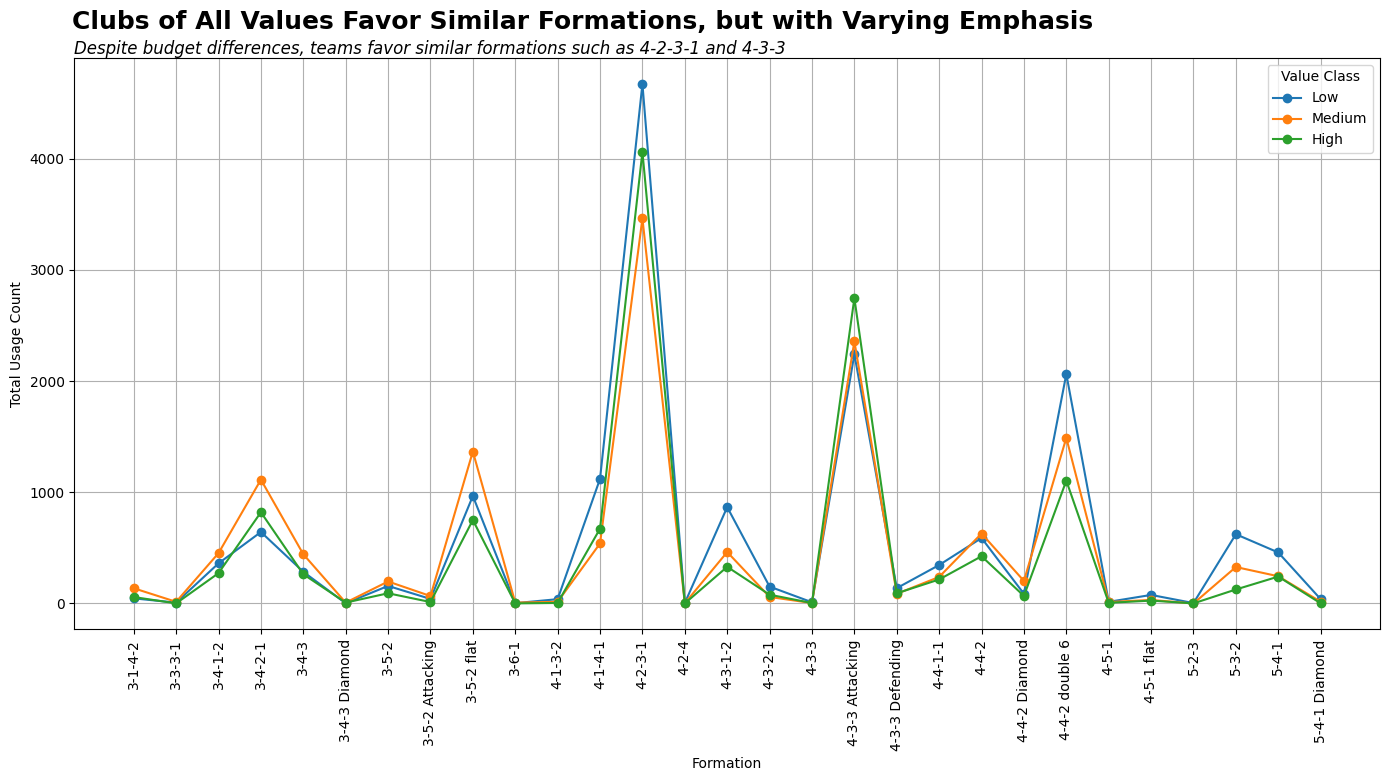

In [16]:
df = formation_count.copy()
formation_diversity = (
    df.groupby(['club_id', 'club_name', 'club_total_market_value'])
      .formation.nunique()
      .reset_index(name='num_formations')
)
df['club_total_market_value'] = pd.to_numeric(
    df['club_total_market_value'],
    errors='coerce'   # non-numeric -> NaN
)

# (optional) drop rows where market value is missing
df = df.dropna(subset=['club_total_market_value'])

# ---------- 1) Formation diversity per club ----------
formation_diversity = (
    df.groupby(['club_id', 'club_name', 'club_total_market_value'])
      .formation.nunique()
      .reset_index(name='num_formations')
)

# Define value classes: 0–150M = Low, 150–400M = Medium, 400M+ = High
bins = [0, 150_000_000, 400_000_000, np.inf]
labels = ['Low', 'Medium', 'High']

formation_diversity['value_class'] = pd.cut(
    formation_diversity['club_total_market_value'],
    bins=bins,
    labels=labels,
    right=False  
)

# --- A: avg number of formations per value class ---
div_summary = (
    formation_diversity
    .groupby('value_class')['num_formations']
    .mean()
    .reindex(labels)
)

df['value_class'] = pd.cut(
    df['club_total_market_value'],
    bins=bins,
    labels=labels,
    right=False
)

# ----------------------------------------------
# 2) Aggregate formation usage per value class
# ----------------------------------------------
formation_pref = (
    df.groupby(['value_class', 'formation'])
      .formation_count.sum()
      .reset_index()
)

# ----------------------------------------------
# 3) Plot formation preference for each value class
# ----------------------------------------------
plt.figure(figsize=(14,8))

for val_class in labels:
    subset = formation_pref[formation_pref['value_class'] == val_class]
    plt.plot(subset['formation'], subset['formation_count'], marker='o', label=val_class)

plt.xticks(rotation=90)
plt.xlabel("Formation")
plt.ylabel("Total Usage Count")
plt.suptitle(
    "Clubs of All Values Favor Similar Formations, but with Varying Emphasis",
    fontsize=18, weight='bold', y=0.97, x=0.055, ha='left'
)
plt.title(
    "Despite budget differences, teams favor similar formations such as 4-2-3-1 and 4-3-3",
    fontsize=12, style='italic', pad=2, loc='left'
)
plt.legend(title="Value Class")
plt.grid(True)
plt.tight_layout()
plt.show()

How I Got to the Graph

Built club market values:
Since clubs didn’t have a total value in the dataset, I computed each club’s total_market_value by summing the market value of all its players.

Counted formation usage per club:
From the games table, I pulled both home and away team formations for Big 5 leagues, stacked them together, joined to clubs, and counted how many times each club used each formation.

Classified clubs by budget:
I converted each club’s total market value into three buckets:
Low: €0–150M
Medium: €150–400M
High: €400M+

Aggregated by value class:
I summed formation usage counts within each value class to get how often every formation was used by Low/Medium/High-value clubs.

Plotted the lines:
Using Matplotlib, I plotted formation (x-axis) vs total usage count (y-axis), with one line per value class and labeled axes/titles for readability.

What the Graph Shows:
All budget tiers favor similar formations, especially 4-2-3-1 and 4-3-3.
Differences are mostly in emphasis (how often a formation is used), not in which formations are chosen.
Higher-value and medium-value clubs often show larger usage counts for the popular systems, while lower-value clubs follow a similar pattern at a smaller scale.

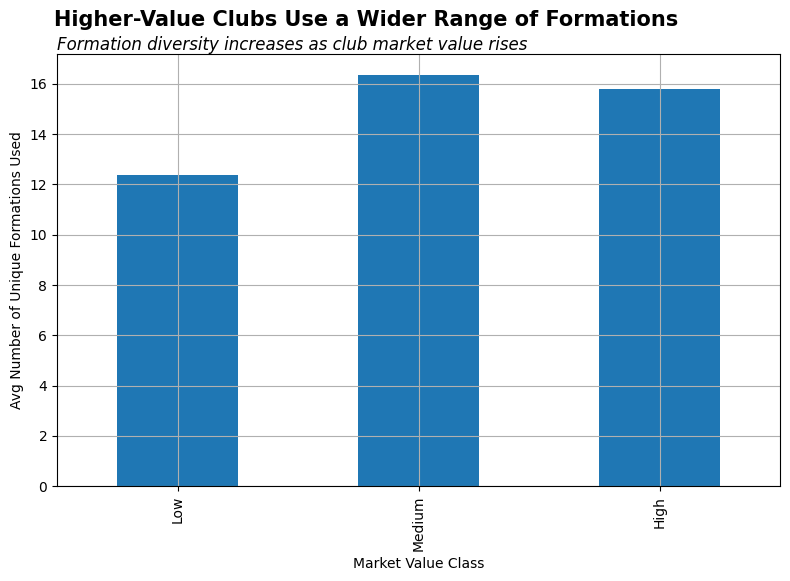

In [18]:

plt.figure(figsize=(8,6))
div_summary.plot(kind='bar')
plt.xlabel("Market Value Class")
plt.ylabel("Avg Number of Unique Formations Used")
plt.suptitle(
    "Higher-Value Clubs Use a Wider Range of Formations",
    fontsize=15, weight='bold', y=0.96, x=0.074, ha='left'
)
plt.title(
    "Formation diversity increases as club market value rises",
    fontsize=12, style='italic', pad=2, loc='left'
)
plt.grid(True)
plt.tight_layout()
plt.show()